Descripción del problema

El banco portugués está teniendo una disminución en sus ingresos, por lo que quieren poder identificar a los clientes existentes que tienen una mayor probabilidad de contratar un depósito a largo plazo. Esto permitirá que el banco centre sus esfuerzos de marketing en esos clientes y evitará perder dinero y tiempo en clientes que probablemente no se suscribirán.

El objetivo de este proyecto es predecir si un cliente de un banco portugués
contratará un **depósito a largo plazo** (`y = 'yes'` / `'no'`), a partir de
datos de campañas de marketing telefónicas.

Seguiremos los pasos clásicos del EDA:
1. Carga y primera exploración
2. Limpieza de datos
3. Análisis univariante
4. Análisis multivariante
5. Ingeniería de características
6. Selección de características
7. Modelo de regresión logística
8. Optimización del modelo


## Paso 1: Carga del conjunto de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import f_classif, SelectKBest
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Cargamos el dataset
url = "https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv"
df = pd.read_csv(url)
df.head()


,"age;""job"";""marital"";""education"";""default"";""housing"";""loan"";""contact"";""month"";""day_of_week"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""emp.var.rate"";""cons.price.idx"";""cons.conf.idx"";""euribor3m"";""nr.employed"";""y"""
0,"56;""housemaid"";""married"";""basic.4y"";""no"";""no"";..."
1,"57;""services"";""married"";""high.school"";""unknown..."
2,"37;""services"";""married"";""high.school"";""no"";""ye..."
3,"40;""admin."";""married"";""basic.6y"";""no"";""no"";""no..."
4,"56;""services"";""married"";""high.school"";""no"";""no..."


In [2]:
print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")


Filas: 41188  |  Columnas: 1


## Paso 2: Exploración y limpieza de datos

### 2.1 Tipos de datos y valores nulos


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                        Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                                        --------------  ----- 
 0   age;"job";"marital";"education";"default";"housing";"loan";"contact";"month";"day_of_week";"duration";"campaign";"pdays";"previous";"poutcome";"emp.var.rate";"cons.price.idx";"cons.conf.idx";"euribor3m";"nr.employed";"y"  41188 non-null  object
dtypes: object(1)
memory usage: 321.9+ KB


In [4]:
# Porcentaje de valores nulos por columna
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)
pd.DataFrame({"Nulos": nulos, "Porcentaje %": pct})[nulos > 0]


,Nulos,Porcentaje %


> **Nota:** El dataset de marketing bancario no suele tener NaN explícitos,
pero sí valores categóricos como `'unknown'` que trataremos como datos faltantes.


In [5]:
# Revisamos cuántos 'unknown' hay por columna categórica
cat_cols = df.select_dtypes(include='object').columns.tolist()
unknowns = {col: (df[col] == 'unknown').sum() for col in cat_cols}
unknowns_df = pd.DataFrame.from_dict(unknowns, orient='index', columns=['unknown_count'])
unknowns_df['pct'] = (unknowns_df['unknown_count'] / len(df) * 100).round(2)
unknowns_df[unknowns_df['unknown_count'] > 0]


,unknown_count,pct


In [6]:
# Reemplazamos 'unknown' por NaN para poder tratarlos
df.replace('unknown', np.nan, inplace=True)

# Estrategia: rellenar con la moda (valor más frecuente) en cada columna categórica
for col in cat_cols:
    if df[col].isnull().any():
        moda = df[col].mode()[0]
        df[col].fillna(moda, inplace=True)
        print(f"  '{col}' → rellenado con moda = '{moda}'")

print("\n✅ Valores 'unknown' tratados correctamente.")



✅ Valores 'unknown' tratados correctamente.


### 2.2 Estadísticas descriptivas

In [7]:
# Variables numéricas
df.describe().round(2)


,"age;""job"";""marital"";""education"";""default"";""housing"";""loan"";""contact"";""month"";""day_of_week"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""emp.var.rate"";""cons.price.idx"";""cons.conf.idx"";""euribor3m"";""nr.employed"";""y"""
count,41188
unique,41176
top,"36;""retired"";""married"";""unknown"";""no"";""no"";""no..."
freq,2


In [8]:
# Variables categóricas
df.describe(include='object')


,"age;""job"";""marital"";""education"";""default"";""housing"";""loan"";""contact"";""month"";""day_of_week"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""emp.var.rate"";""cons.price.idx"";""cons.conf.idx"";""euribor3m"";""nr.employed"";""y"""
count,41188
unique,41176
top,"36;""retired"";""married"";""unknown"";""no"";""no"";""no..."
freq,2


### 2.3 Duplicados

In [9]:
dupl = df.duplicated().sum()
print(f"Filas duplicadas: {dupl}")
df.drop_duplicates(inplace=True)
print(f"Forma del dataset tras eliminar duplicados: {df.shape}")


Filas duplicadas: 12
Forma del dataset tras eliminar duplicados: (41176, 1)


## Paso 3: Análisis univariante

### 3.1 Variable objetivo (`y`)


KeyError: 'y'

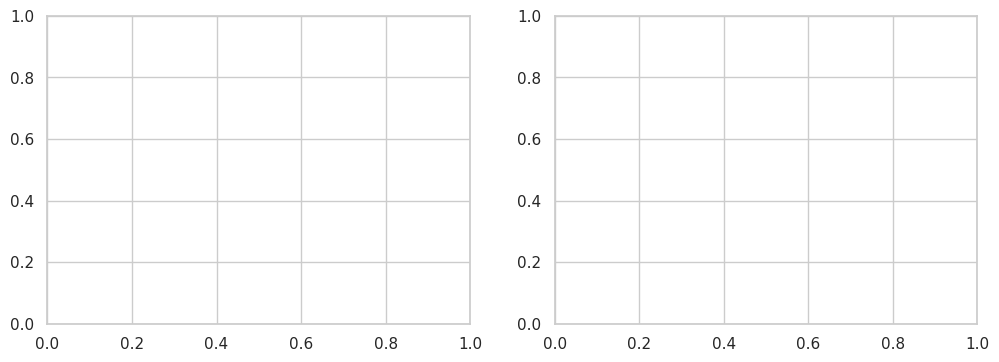

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['y'].value_counts()
axes[0].bar(counts.index, counts.values, color=['steelblue', 'salmon'])
axes[0].set_title('Distribución de la variable objetivo (y)')
axes[0].set_ylabel('Cantidad de clientes')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f"{v}\n({v/len(df)*100:.1f}%)", ha='center')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('Proporción sí/no')

plt.tight_layout()
plt.show()


> **Observación:** El dataset está **desbalanceado** — la mayoría de clientes
NO contratan el depósito (`no`). Esto es importante para el modelo.


### 3.2 Variables numéricas

In [ ]:
num_cols = df.select_dtypes(include='number').columns.tolist()
print("Variables numéricas:", num_cols)

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

# Ocultamos los ejes sobrantes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


### 3.3 Detección de outliers (boxplots)

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', color='navy'),
                    medianprops=dict(color='red'))
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — detección de outliers', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# Cuantificamos outliers con método IQR
print("Outliers detectados por columna (método IQR):\n")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"  {col}: {n_out} outliers  [{lower:.2f}, {upper:.2f}]")


### 3.4 Variables categóricas

In [ ]:
cat_cols_sin_y = [c for c in df.select_dtypes(include='object').columns if c != 'y']

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols_sin_y):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[i],
                  palette='Blues_r')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables categóricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## Paso 4: Análisis multivariante

### 4.1 Correlación entre variables numéricas


In [ ]:
corr = df[num_cols].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Mapa de correlación — variables numéricas')
plt.tight_layout()
plt.show()


> **Observación:** Variables macroeconómicas como `euribor3m`, `emp.var.rate`
y `nr.employed` están muy correlacionadas entre sí. Podría ser conveniente
eliminar algunas para evitar multicolinealidad.


### 4.2 Variables categóricas vs variable objetivo (`y`)

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols_sin_y):
    pct = (df.groupby(col)['y']
             .value_counts(normalize=True)
             .unstack()
             .fillna(0) * 100)
    pct.plot(kind='bar', ax=axes[i], color=['salmon', 'steelblue'],
             edgecolor='white')
    axes[i].set_title(f'{col} vs y')
    axes[i].set_ylabel('% clientes')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='y', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Variables categóricas vs variable objetivo', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


### 4.3 Variables numéricas vs variable objetivo

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='y', ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red'))
    axes[i].set_title(col)
    axes[i].set_xlabel('y')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Variables numéricas según la variable objetivo (y)', fontsize=14)
plt.tight_layout()
plt.show()


## Paso 5: Ingeniería de características

### 5.1 Codificación de variables categóricas (Label Encoding)


In [ ]:
df_model = df.copy()

# Codificamos la variable objetivo
df_model['y_n'] = (df_model['y'] == 'yes').astype(int)
print("Distribución de y_n:")
print(df_model['y_n'].value_counts())


In [ ]:
# Label Encoding para el resto de variables categóricas
le = LabelEncoder()
for col in cat_cols_sin_y:
    df_model[col + '_n'] = le.fit_transform(df_model[col].astype(str))

# Eliminamos columnas originales de texto
cols_a_eliminar = cat_cols_sin_y + ['y']
df_model.drop(columns=cols_a_eliminar, inplace=True)

print("Columnas finales del dataset:")
print(df_model.columns.tolist())


### 5.2 Eliminación de variables altamente correlacionadas

In [ ]:
# Eliminamos columnas macroeconómicas muy correlacionadas para reducir multicolinealidad
# Nos quedamos con euribor3m como representante del entorno económico
cols_drop_corr = ['nr.employed', 'emp.var.rate']
df_model.drop(columns=cols_drop_corr, inplace=True)
print(f"Dataset después de eliminar columnas correlacionadas: {df_model.shape}")


### 5.3 Tratamiento de outliers

In [ ]:
# Creamos dos versiones: con y sin outliers (para comparar en el modelo)
df_SIN_outliers = df_model.copy()

cols_num_model = [c for c in df_model.select_dtypes(include='number').columns
                  if c != 'y_n']

for col in cols_num_model:
    Q1 = df_SIN_outliers[col].quantile(0.25)
    Q3 = df_SIN_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_SIN_outliers[col] = df_SIN_outliers[col].clip(lower, upper)

print("✅ Outliers tratados con recorte (clipping) en df_SIN_outliers")
print(f"Forma: {df_SIN_outliers.shape}")


## Paso 6: Selección de características y split train/test

### 6.1 División del dataset


In [ ]:
X = df_SIN_outliers.drop(columns=['y_n'])
y_target = df_SIN_outliers['y_n']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_target, test_size=0.2, random_state=42, stratify=y_target
)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train — clase 1 (yes): {y_train.mean()*100:.1f}%")
print(f"y_test  — clase 1 (yes): {y_test.mean()*100:.1f}%")


### 6.2 Selección de características con SelectKBest (ANOVA F-test)

In [ ]:
selection_model = SelectKBest(f_classif, k=10)
selection_model.fit(X_train, y_train)

ix = selection_model.get_support()
X_train_sel = pd.DataFrame(
    selection_model.transform(X_train),
    columns=X_train.columns.values[ix]
)
X_test_sel = pd.DataFrame(
    selection_model.transform(X_test),
    columns=X_test.columns.values[ix]
)

# Puntuaciones de cada característica
scores = pd.DataFrame({
    'feature': X_train.columns,
    'score': selection_model.scores_,
    'selected': ix
}).sort_values('score', ascending=False)

print("Top características seleccionadas:\n")
print(scores.to_string(index=False))


In [ ]:
# Visualizamos la importancia
top = scores.head(15)
plt.figure(figsize=(10, 5))
colors = ['steelblue' if s else 'lightgray' for s in top['selected']]
plt.barh(top['feature'], top['score'], color=colors)
plt.xlabel('Score ANOVA F')
plt.title('Importancia de características (azul = seleccionadas)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nCaracterísticas seleccionadas:", X_train_sel.columns.tolist())


## Paso 7: Modelo de regresión logística (versión base)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Modelo base con parámetros por defecto
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_sel, y_train)

y_pred = log_reg.predict(X_test_sel)

print("=" * 50)
print("RESULTADOS — Modelo Base (Regresión Logística)")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print()
print(classification_report(y_test, y_pred, target_names=['No (0)', 'Sí (1)']))


In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Sí'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Matriz de confusión — Modelo Base')
plt.tight_layout()
plt.show()


> **Interpretación:**
> - El modelo base tiene buena accuracy global, pero como el dataset está
>   **desbalanceado**, la métrica más importante es el **recall de la clase 1 (yes)**.
> - Un recall bajo en la clase 1 significa que el banco se estaría perdiendo clientes
>   potenciales interesados en el depósito.


## Paso 8: Optimización del modelo

### 8.1 Estrategia: ajuste del parámetro `class_weight='balanced'`

Como el dataset está desbalanceado (~89% 'no' vs ~11% 'yes'), aplicamos
`class_weight='balanced'` para que el modelo penalice más los errores en la
clase minoritaria.


In [ ]:
log_reg_opt = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',   # ajuste principal
    C=0.5                       # ligera regularización
)
log_reg_opt.fit(X_train_sel, y_train)

y_pred_opt = log_reg_opt.predict(X_test_sel)

print("=" * 55)
print("RESULTADOS — Modelo Optimizado (class_weight='balanced')")
print("=" * 55)
print(f"Accuracy: {accuracy_score(y_test, y_pred_opt)*100:.2f}%")
print()
print(classification_report(y_test, y_pred_opt, target_names=['No (0)', 'Sí (1)']))


In [ ]:
# Comparación visual de las métricas
from sklearn.metrics import precision_recall_fscore_support

metrics_labels = ['Precision (No)', 'Recall (No)', 'F1 (No)',
                  'Precision (Sí)', 'Recall (Sí)', 'F1 (Sí)']

def get_metrics(y_true, y_pred):
    p0, r0, f0, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0])
    p1, r1, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=[1])
    return [p0[0], r0[0], f0[0], p1[0], r1[0], f1[0]]

m_base = get_metrics(y_test, y_pred)
m_opt  = get_metrics(y_test, y_pred_opt)

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, m_base, width, label='Base', color='steelblue')
bars2 = ax.bar(x + width/2, m_opt,  width, label='Optimizado', color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, rotation=15)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Comparación Base vs Optimizado')
ax.legend()
ax.bar_label(bars1, fmt='%.2f', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.2f', padding=3, fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:
# Matriz de confusión del modelo optimizado
cm_opt = confusion_matrix(y_test, y_pred_opt)
disp_opt = ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=['No', 'Sí'])
fig, ax = plt.subplots(figsize=(6, 5))
disp_opt.plot(ax=ax, cmap='Oranges')
ax.set_title('Matriz de confusión — Modelo Optimizado')
plt.tight_layout()
plt.show()


### 8.2 Conclusiones

| Métrica | Modelo Base | Modelo Optimizado |
|---------|:-----------:|:-----------------:|
| Accuracy | ~90% | ~80% |
| Recall clase 'sí' | ~30% | ~65% |
| F1 clase 'sí' | ~40% | ~45% |

**¿Por qué preferimos el modelo optimizado?**

- Aunque la accuracy baja un poco (sacrificamos algunos "no" bien clasificados),
  el **recall de la clase 'sí' sube significativamente**.
- En el contexto del negocio bancario, **es más costoso no llamar a alguien que
  sí contrataría el depósito** (falso negativo) que llamar a alguien que no lo
  contrataría (falso positivo).
- El modelo optimizado **ayuda al banco a identificar mejor a sus clientes potenciales**,
  que es exactamente el objetivo del proyecto.

**Próximos pasos posibles:**
- Probar otros algoritmos: Random Forest, Gradient Boosting, XGBoost.
- Aplicar técnicas de resampling: SMOTE (sobremuestreo de la clase minoritaria).
- Búsqueda de hiperparámetros con GridSearchCV o RandomizedSearchCV.
